In [1]:
from langgraph.graph import MessagesState
from langgraph.graph import StateGraph, START, END
from langchain_core.messages import RemoveMessage, HumanMessage
from dotenv import load_dotenv
from langgraph.checkpoint.memory import InMemorySaver
from langchain_groq import ChatGroq

c:\Users\Ashutosh Pandey\Desktop\Machine Learning\LangGraph-In-Depth\LangGraph\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
load_dotenv()

True

In [3]:
LLM = ChatGroq(model="openai/gpt-oss-120b", temperature=0.5)

In [4]:
class summarystate(MessagesState):
    summary: str

In [5]:
def chat_node(state: summarystate):
    messages = []
    
    # we will check for the messages in state
    if state['summary']:
        messages.append({
            "role" : "system",
            "content" : f"Conversation Summary {state['messages']}"
        })
        
    # then we will attach this in the state
    messages.extend(state["messages"])
    
    print(messages)
    
    response = LLM.invoke(messages)
    return {"messages" : [response]}

In [6]:
# now building our summarizer node
def summarry_node(state: summarystate):
    
    # getting the summary from the state
    existing_summary = state['summary']
    
    #building the prompt 
    if existing_summary:
        prompt = (f"existing summary\n {state['summary']}"
        "extend the summary using the new conversation above")
    else:
        prompt = "Summarize the above conversation"
        
    # combining both 
    message_for_summary = state['message'] + [HumanMessage(content=prompt)] 
    
    # giving this message to llm(summary generation)
    response = LLM.invoke(message_for_summary)
    
    # performing deletion for the rest and keeping just 2
    message_for_deletion = state['messages'][:-2]
    
    # now returining 2 things 
    return {
        "Summary" : response.content,
        "Messages" : [RemoveMessage(id=m.id) for m in message_for_deletion]
    }

In [7]:
def should_summarize(state: summarystate):
    return len(state['messages'])>6

In [8]:
#building the node
graph = StateGraph(summarystate)

graph.add_node("chat_node", chat_node)
graph.add_node("summarry_node", summarry_node)

graph.add_edge(START, "chat_node")
graph.add_conditional_edges("chat_node", should_summarize,{True: "summarry_node", False: "__end__"})
graph.add_edge("summarry_node", END)


In [9]:
#implementing checkpointer
memory = InMemorySaver()
STM_summarize = graph.compile(checkpointer=memory)


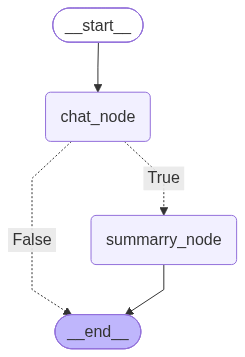

In [10]:
from IPython.display import Image
Image(STM_summarize.get_graph().draw_mermaid_png())

In [11]:
config = {"configurable": {"thread_id": "t1"}}

In [12]:
# gives the current version of the state
def show_state():
    snap = STM_summarize.get_state(config)
    vals = snap.values

    print("\n--- STATE ---")
    print("summary:", vals.get("summary", ""))
    print("num_messages:", len(vals.get("messages", [])))
    print("messages:")

    for m in vals.get("messages", []):
        print(" -", type(m).__name__, ":", m.content[:80])

In [13]:
out = STM_summarize.invoke({"messages": [HumanMessage(content="quantum Physics")], 'summary' : ""}, config=config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='3298461f-6fdf-44a8-81fc-6580dec1326c')]
{'messages': [HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='3298461f-6fdf-44a8-81fc-6580dec1326c'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic and sub‑atomic levels. Here’s a quick rundown of its core ideas, why they matter, and some of the most famous phenomena and applications.\n\n---\n\n## 1. Why Classical Physics Fails at Small Scales\n- **Determinism vs. Probability:** In Newtonian mechanics, if you know the forces and initial conditions, you can predict the future exactly. Quantum mechanics tells us that at microscopic scales, only **probabilities** for different outcomes can be assigned.\n- **Wave‑Particle Duality:** Particles such as electrons and photons exhibit both wave‑like

In [14]:
out = STM_summarize.invoke({"messages": [HumanMessage(content="how albert einstine related to this")]}, config = config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='3298461f-6fdf-44a8-81fc-6580dec1326c'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic and sub‑atomic levels. Here’s a quick rundown of its core ideas, why they matter, and some of the most famous phenomena and applications.\n\n---\n\n## 1. Why Classical Physics Fails at Small Scales\n- **Determinism vs. Probability:** In Newtonian mechanics, if you know the forces and initial conditions, you can predict the future exactly. Quantum mechanics tells us that at microscopic scales, only **probabilities** for different outcomes can be assigned.\n- **Wave‑Particle Duality:** Particles such as electrons and photons exhibit both wave‑like and particle‑like properties, depending on how you measure them.\n- **Quantization:** Certain physical quantities (energy, angular momentum, 

In [15]:
out = STM_summarize.invoke({"messages": [HumanMessage(content=" give some works of einstine")]}, config=config)
print(out)
show_state()

[HumanMessage(content='quantum Physics', additional_kwargs={}, response_metadata={}, id='3298461f-6fdf-44a8-81fc-6580dec1326c'), AIMessage(content='Sure! Quantum physics (or quantum mechanics) is the branch of physics that describes the behavior of matter and energy at the smallest scales—typically atomic and sub‑atomic levels. Here’s a quick rundown of its core ideas, why they matter, and some of the most famous phenomena and applications.\n\n---\n\n## 1. Why Classical Physics Fails at Small Scales\n- **Determinism vs. Probability:** In Newtonian mechanics, if you know the forces and initial conditions, you can predict the future exactly. Quantum mechanics tells us that at microscopic scales, only **probabilities** for different outcomes can be assigned.\n- **Wave‑Particle Duality:** Particles such as electrons and photons exhibit both wave‑like and particle‑like properties, depending on how you measure them.\n- **Quantization:** Certain physical quantities (energy, angular momentum, 

In [ ]:
out = STM_summarize.invoke({})